![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 4: Stable Diffusion & Latent Diffusion

This notebook connects **denoising diffusion** to **latent diffusion** and **Stable Diffusion** — forward noising, VAE latents, CLIP conditioning, U-Net cross-attention, and full pipeline inference.

You will build each stack component in PyTorch (patterns from the [LabML annotated Stable Diffusion implementation](https://github.com/labmlai/annotated_deep_learning_paper_implementations/tree/master/labml_nn/diffusion/stable_diffusion/model)), then run Hugging Face inference.

> 💡 Stable Diffusion runs diffusion in **latent space** (VAE) with **text conditioning** (CLIP + cross-attention). Map each code block to that stack.

__Let's install libraries and build the Stable Diffusion stack step by step.__



# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch** — Diffusion math, VAE, and attention modules.
- **Diffusers** — Stable Diffusion pipeline (VAE + U-Net + CLIP bundled).
- **Transformers** — CLIP text encoder (`CLIPTextModel`).
- **Matplotlib / NumPy** — Visualizing samples and latent shapes.


In [1]:
!pip install -q torch torchvision transformers diffusers accelerate matplotlib numpy scipy datasets


# 📥 Importing Essential Python Libraries

Core imports for diffusion math and optional Stable Diffusion inference.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch 2.11.0+cpu
CUDA available: False


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: forward/reverse diffusion, DDPM training, latent diffusion (LDM), Stable Diffusion stack.*

### 📖 A1. Diffusion fundamentals

1. Describe the **forward** and **reverse** processes in one sentence each.
2. In DDPM training, does the network predict $x_0$, $\epsilon$, or $v$? Why is noise prediction common?
3. Why is pure pixel-space diffusion expensive for high-resolution images?

*Write below:*


#### ✍️ Your answers (A1):

1. **Forward:** gradually add Gaussian noise to data over timesteps until samples become nearly pure noise. **Reverse:** learn to denoise step-by-step to recover data from noise.

2. DDPM commonly predicts **noise $\epsilon$** because it stabilizes training and is equivalent (with reparameterization) to predicting $x_0$ or $v$-targets; noise targets have **near-unit variance** across timesteps.

3. Pixel-space diffusion at high resolution requires operating on **millions of dimensions per image**, making each denoising step **prohibitively expensive** in memory and compute.

### 📖 A2. Latent Diffusion / Stable Diffusion

1. What are the roles of the **VAE**, **U-Net**, and **text encoder** in Stable Diffusion?
2. Name two practical issues (artifacts, bias, safety) discussed in the lecture.
3. How does **classifier-free guidance** trade off diversity vs prompt adherence?

*Write below:*


#### ✍️ Your answers (A2):

1. **VAE** compresses images to **latent tensors**; **U-Net** denoises latents conditioned on timestep; **text encoder (CLIP)** supplies **cross-attention** conditioning from prompts.

2. Lecture issues include **anatomical artifacts** (extra fingers), **cultural/bias** in generated content, and **safety** (NSFW or harmful generations without guardrails).

3. **Classifier-free guidance** increases conditional score influence vs unconditional — **stronger prompt adherence** but often **reduced diversity** and possible **over-saturation**.

---

## 💻 Part B — Programming
__Let's implement the core Stable Diffusion stack in PyTorch.__

### 🛠️ B1. Forward diffusion (DDPM)

The forward process gradually adds Gaussian noise. Training uses the closed form
$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon$$
so we can sample noisy latents at arbitrary timesteps without iterating (see lecture forward-process slides).

In [3]:
def linear_beta_schedule(T: int, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def q_sample(x0, t, betas, noise=None):
    """Sample x_t given x_0 using closed-form Gaussian diffusion."""
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    ab = alpha_bar[t].view(-1, 1, 1, 1)
    if noise is None:
        noise = torch.randn_like(x0)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise

T = 200
betas = linear_beta_schedule(T)
x0 = torch.randn(1, 4, 16, 16)  # toy latent-sized tensor
for t_val in [0, 50, 100, 150, 199]:
    xt = q_sample(x0, torch.tensor([t_val]), betas)
    print(f"t={t_val:3d} | mean={xt.mean():.3f} std={xt.std():.3f}")

t=  0 | mean=-0.066 std=1.011
t= 50 | mean=-0.076 std=1.019
t=100 | mean=-0.033 std=1.047
t=150 | mean=-0.048 std=1.022
t=199 | mean=-0.044 std=0.991


### 🛠️ B2. VAE autoencoder & Gaussian latents

Stable Diffusion diffuses in **VAE latent space**, not pixels. The encoder maps an image to moments $(\mu, \log\sigma^2)$; we sample $z = \mu + \sigma\odot\epsilon$ and decode back to pixels.

In [4]:
class GaussianDistribution:
    """LabML-style latent distribution (autoencoder.py)."""
    def __init__(self, parameters: torch.Tensor):
        self.mean, log_var = torch.chunk(parameters, 2, dim=1)
        self.log_var = torch.clamp(log_var, -30.0, 20.0)
        self.std = torch.exp(0.5 * self.log_var)

    def sample(self):
        return self.mean + self.std * torch.randn_like(self.std)

class TinyEncoder(nn.Module):
    def __init__(self, in_ch=3, z_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(64, 2 * z_ch, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)

class TinyDecoder(nn.Module):
    def __init__(self, out_ch=3, z_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_ch, 64, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(32, out_ch, 3, padding=1),
        )

    def forward(self, z):
        return self.net(z)

class TinyAutoencoder(nn.Module):
    def __init__(self, z_ch=4):
        super().__init__()
        self.encoder = TinyEncoder(z_ch=z_ch)
        self.decoder = TinyDecoder(z_ch=z_ch)

    def encode(self, img):
        return GaussianDistribution(self.encoder(img))

    def decode(self, z):
        return self.decoder(z)

ae = TinyAutoencoder()
img = torch.rand(2, 3, 32, 32)
posterior = ae.encode(img)
z = posterior.sample()
recon = ae.decode(z)
print(f"Input {tuple(img.shape)} → latent {tuple(z.shape)} → recon {tuple(recon.shape)}")
print(f"Reconstruction MSE: {F.mse_loss(recon, img).item():.4f}")

Input (2, 3, 32, 32) → latent (2, 4, 8, 8) → recon (2, 3, 32, 32)
Reconstruction MSE: 0.3371


### 🛠️ B3. CLIP text conditioning

 Prompts become token sequences; CLIP's text transformer outputs embeddings $c$ that feed the U-Net via cross-attention. Each prompt yields shape `[batch, 77, 768]` for SD v1.x.

In [5]:
def clip_text_embeddings(prompts, model_name="openai/clip-vit-base-patch32", max_length=77):
    """Return CLIP token embeddings [B, seq, d_cond] (clip_embedder.py pattern)."""
    from transformers import CLIPTokenizer, CLIPTextModel

    tokenizer = CLIPTokenizer.from_pretrained(model_name)
    transformer = CLIPTextModel.from_pretrained(model_name).eval()
    batch = tokenizer(
        prompts, truncation=True, max_length=max_length,
        padding="max_length", return_tensors="pt",
    )
    with torch.no_grad():
        return transformer(input_ids=batch["input_ids"]).last_hidden_state

try:
    prompts = [
        "a futuristic building in the Saudi desert at sunset",
        "a cat sitting on a windowsill",
    ]
    cond = clip_text_embeddings(prompts)
    print(f"CLIP conditioning shape: {tuple(cond.shape)}  (batch, tokens, dim)")
except Exception as exc:
    print(f"CLIP demo skipped ({exc}). Using random conditioning tensor.")
    cond = torch.randn(2, 77, 512)
    print(f"Fallback conditioning shape: {tuple(cond.shape)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

CLIP conditioning shape: (2, 77, 512)  (batch, tokens, dim)


### 🛠️ B4. U-Net cross-attention block

 At each spatial location the U-Net runs **self-attention** over pixels, then **cross-attention** to CLIP tokens, then a feed-forward block:
$$\text{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$
Queries come from the feature map; keys/values come from CLIP conditioning $c$.

In [6]:
class CrossAttention(nn.Module):
    """Simplified CrossAttention from unet_attention.py (normal_attention path)."""
    def __init__(self, d_model: int, d_cond: int, n_heads: int = 4):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.scale = self.d_head ** -0.5
        d_attn = self.d_head * n_heads
        self.to_q = nn.Linear(d_model, d_attn, bias=False)
        self.to_k = nn.Linear(d_cond, d_attn, bias=False)
        self.to_v = nn.Linear(d_cond, d_attn, bias=False)
        self.to_out = nn.Linear(d_attn, d_model)

    def forward(self, x, cond=None):
        if cond is None:
            cond = x
        q = self.to_q(x).view(*x.shape[:2], self.n_heads, self.d_head)
        k = self.to_k(cond).view(*cond.shape[:2], self.n_heads, self.d_head)
        v = self.to_v(cond).view(*cond.shape[:2], self.n_heads, self.d_head)
        attn = torch.einsum("bihd,bjhd->bhij", q, k) * self.scale
        attn = attn.softmax(dim=-1)
        out = torch.einsum("bhij,bjhd->bihd", attn, v)
        return self.to_out(out.reshape(*x.shape[:2], -1))

class BasicTransformerBlock(nn.Module):
    def __init__(self, d_model: int, d_cond: int, n_heads: int = 4):
        super().__init__()
        self.attn1 = CrossAttention(d_model, d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.attn2 = CrossAttention(d_model, d_cond, n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Linear(d_model * 4, d_model))
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, cond):
        x = self.attn1(self.norm1(x)) + x
        x = self.attn2(self.norm2(x), cond=cond) + x
        x = self.ff(self.norm3(x)) + x
        return x

class SpatialTransformer(nn.Module):
    def __init__(self, channels: int, d_cond: int, n_heads: int = 4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.block = BasicTransformerBlock(channels, d_cond, n_heads)

    def forward(self, x, cond):
        b, c, h, w = x.shape
        residual = x
        x = self.norm(x).permute(0, 2, 3, 1).reshape(b, h * w, c)
        x = self.block(x, cond)
        x = x.view(b, h, w, c).permute(0, 3, 1, 2)
        return x + residual

d_cond = cond.size(-1)
st = SpatialTransformer(channels=64, d_cond=d_cond, n_heads=4)
feat = torch.randn(2, 64, 8, 8)
out = st(feat, cond)
print(f"Feature map {tuple(feat.shape)} + CLIP {tuple(cond.shape)} → {tuple(out.shape)}")

Feature map (2, 64, 8, 8) + CLIP (2, 77, 512) → (2, 64, 8, 8)


### 🛠️ B5. Classifier-free guidance

 At inference, SD combines conditional and unconditional noise predictions:
$$\tilde\epsilon = \epsilon_u + w\,(\epsilon_c - \epsilon_u)$$
Training drops the text condition randomly so both branches exist.

In [7]:
class LatentNoisePredictor(nn.Module):
    """Toy ε_θ(x_t, t, c) with optional unconditional branch."""
    def __init__(self, channels=4, d_cond=512):
        super().__init__()
        self.time_emb = nn.Embedding(1000, channels)
        self.cond_proj = nn.Linear(d_cond, channels)
        self.net = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x, t, cond_vec, drop_cond=False):
        if drop_cond:
            cond_vec = torch.zeros_like(cond_vec)
        h = x + self.time_emb(t).view(-1, x.size(1), 1, 1)
        h = h + self.cond_proj(cond_vec).view(-1, x.size(1), 1, 1)
        return self.net(h)

predictor = LatentNoisePredictor(channels=4, d_cond=cond.size(-1))
x_t = torch.randn(1, 4, 8, 8)
t = torch.tensor([50])
cond_vec = cond[0:1].mean(dim=1)
with torch.no_grad():
    eps_u = predictor(x_t, t, cond_vec, drop_cond=True)
    eps_c = predictor(x_t, t, cond_vec, drop_cond=False)
for w in [1.0, 3.0, 7.5]:
    guided = eps_u + w * (eps_c - eps_u)
    print(f"guidance w={w:.1f} | noise norm={guided.norm():.3f}")

guidance w=1.0 | noise norm=13.055
guidance w=3.0 | noise norm=10.416
guidance w=7.5 | noise norm=13.949


### 🛠️ B6. End-to-end Hugging Face inference

Production Stable Diffusion chains **CLIP → U-Net denoising in VAE latents → VAE decode**.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

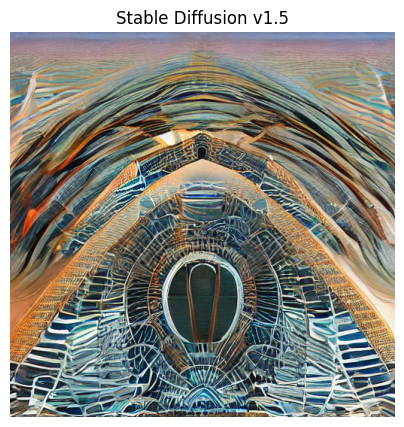

In [8]:
PROMPT = "a futuristic building in the Saudi desert at sunset, digital art"

try:
    from diffusers import StableDiffusionPipeline

    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5", torch_dtype=dtype,
    )
    pipe = pipe.to(device)
    if device == "cpu":
        pipe.set_progress_bar_config(disable=True)
    image = pipe(
        PROMPT,
        num_inference_steps=4 if device == "cpu" else 20,
        guidance_scale=7.5,
    ).images[0]
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Stable Diffusion v1.5")
    plt.show()
except Exception as exc:
    print(f"Pipeline demo skipped ({exc}). Components above implement the same stack at toy scale.")

#### 👀 Reflection

Map each block you implemented to the production stack: **VAE** (B2), **CLIP** (B3), **cross-attention U-Net** (B4), **CFG** (B5), **full pipeline** (B6). Which lecture failure mode (anatomy, text rendering, bias) would you inspect first in your sample?